<a href="https://colab.research.google.com/github/zcybrgd/supervised-learning/blob/main/TP_ANAD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loading des données

In [2]:
!pip install kaggle

In [3]:
import os
os.makedirs('/root/.kaggle/', exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d lainguyn123/employee-survey

Dataset URL: https://www.kaggle.com/datasets/lainguyn123/employee-survey
License(s): other
  0% 0.00/61.1k [00:00<?, ?B/s]
100% 61.1k/61.1k [00:00<00:00, 49.0MB/s]


In [5]:
!unzip employee-survey.zip

Archive:  employee-survey.zip
  inflating: employee_survey.csv     


# Exploration Préliminaire du dataset

In [231]:
#here we put our libraries and frameworks imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [232]:
df = pd.read_csv('employee_survey.csv')
df.head()

,EmpID,Gender,Age,MaritalStatus,JobLevel,Experience,Dept,EmpType,WLB,WorkEnv,...,SleepHours,CommuteMode,CommuteDistance,NumCompanies,TeamSize,NumReports,EduLevel,haveOT,TrainingHoursPerYear,JobSatisfaction
0,6,Male,32,Married,Mid,7,IT,Full-Time,1,1,...,7.6,Car,20,3,12,0,Bachelor,True,33.5,5
1,11,Female,34,Married,Mid,12,Finance,Full-Time,1,1,...,7.9,Car,15,4,11,0,Bachelor,False,36.0,5
2,33,Female,23,Single,Intern/Fresher,1,Marketing,Full-Time,2,4,...,6.5,Motorbike,17,0,30,0,Bachelor,True,10.5,5
3,20,Female,29,Married,Junior,6,IT,Contract,2,2,...,7.5,Public Transport,13,2,9,0,Bachelor,True,23.0,5
4,28,Other,23,Single,Junior,1,Sales,Part-Time,3,1,...,4.9,Car,20,0,7,0,Bachelor,False,20.5,5


In [155]:
df.shape

(3025, 23)

In [156]:
df.describe() # les stats pour les variables quantitatives

,EmpID,Age,Experience,WLB,WorkEnv,PhysicalActivityHours,Workload,Stress,SleepHours,CommuteDistance,NumCompanies,TeamSize,NumReports,TrainingHoursPerYear,JobSatisfaction
count,3025.000000,3025.000000,3025.000000,3025.000000,3025.000000,3025.000000,3025.000000,3025.000000,3025.000000,3025.000000,3025.000000,3025.000000,3025.000000,3025.000000,3025.000000
mean,1513.000000,35.741818,9.082645,3.061157,3.029091,2.029620,2.966612,1.736529,7.005983,13.473719,4.253554,16.516033,2.383140,37.301653,3.386777
std,873.386608,10.191833,7.073344,1.447001,1.415317,0.966014,1.401486,1.064242,1.002652,8.395249,3.382501,6.638419,3.058131,13.569772,1.260599
min,1.000000,22.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,4.000000,1.000000,0.000000,5.000000,0.000000,10.000000,1.000000
25%,757.000000,27.000000,3.000000,2.000000,2.000000,1.300000,2.000000,1.000000,6.300000,6.000000,1.000000,11.000000,0.000000,23.500000,3.000000
50%,1513.000000,34.000000,8.000000,3.000000,3.000000,2.000000,3.000000,1.000000,7.000000,13.000000,4.000000,16.000000,0.000000,40.000000,4.000000
75%,2269.000000,43.000000,14.000000,4.000000,4.000000,2.700000,4.000000,2.000000,7.700000,21.000000,7.000000,22.000000,5.000000,46.500000,4.000000
max,3025.000000,60.000000,29.000000,5.000000,5.000000,5.000000,5.000000,5.000000,10.000000,29.000000,12.000000,30.000000,9.000000,64.500000,5.000000


In [157]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3025 entries, 0 to 3024
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   EmpID                  3025 non-null   int64  
 1   Gender                 3025 non-null   object 
 2   Age                    3025 non-null   int64  
 3   MaritalStatus          3025 non-null   object 
 4   JobLevel               3025 non-null   object 
 5   Experience             3025 non-null   int64  
 6   Dept                   3025 non-null   object 
 7   EmpType                3025 non-null   object 
 8   WLB                    3025 non-null   int64  
 9   WorkEnv                3025 non-null   int64  
 10  PhysicalActivityHours  3025 non-null   float64
 11  Workload               3025 non-null   int64  
 12  Stress                 3025 non-null   int64  
 13  SleepHours             3025 non-null   float64
 14  CommuteMode            3025 non-null   object 
 15  Comm

In [158]:
df.isna().sum()

,0
EmpID,0
Gender,0
Age,0
MaritalStatus,0
JobLevel,0
Experience,0
Dept,0
EmpType,0
WLB,0
WorkEnv,0


In [12]:
df.duplicated().sum()

0

### observing the distribution of our quantitative data

In [13]:
quant_features_int = ['Age','Experience','WLB','WorkEnv','Workload','Stress','CommuteDistance','NumCompanies','TeamSize','NumReports','JobSatisfaction']
quant_features_float = ['PhysicalActivityHours','SleepHours','TrainingHoursPerYear']

In [14]:
def data_distribution(col_list, columns, rows):
    total_plots = len(col_list)
    plt.figure(figsize=(columns * 6, rows * 4))

    for i, col in enumerate(col_list, 1):
        plt.subplot(rows, columns, i)
        df[col].hist(bins=20, alpha=0.7, edgecolor='orange')
        plt.title('Distribution de ' + str(col), fontsize=14)
        plt.xlabel(col, fontsize=12)
        plt.ylabel('Fréquence', fontsize=12)

    plt.tight_layout()
    plt.show()

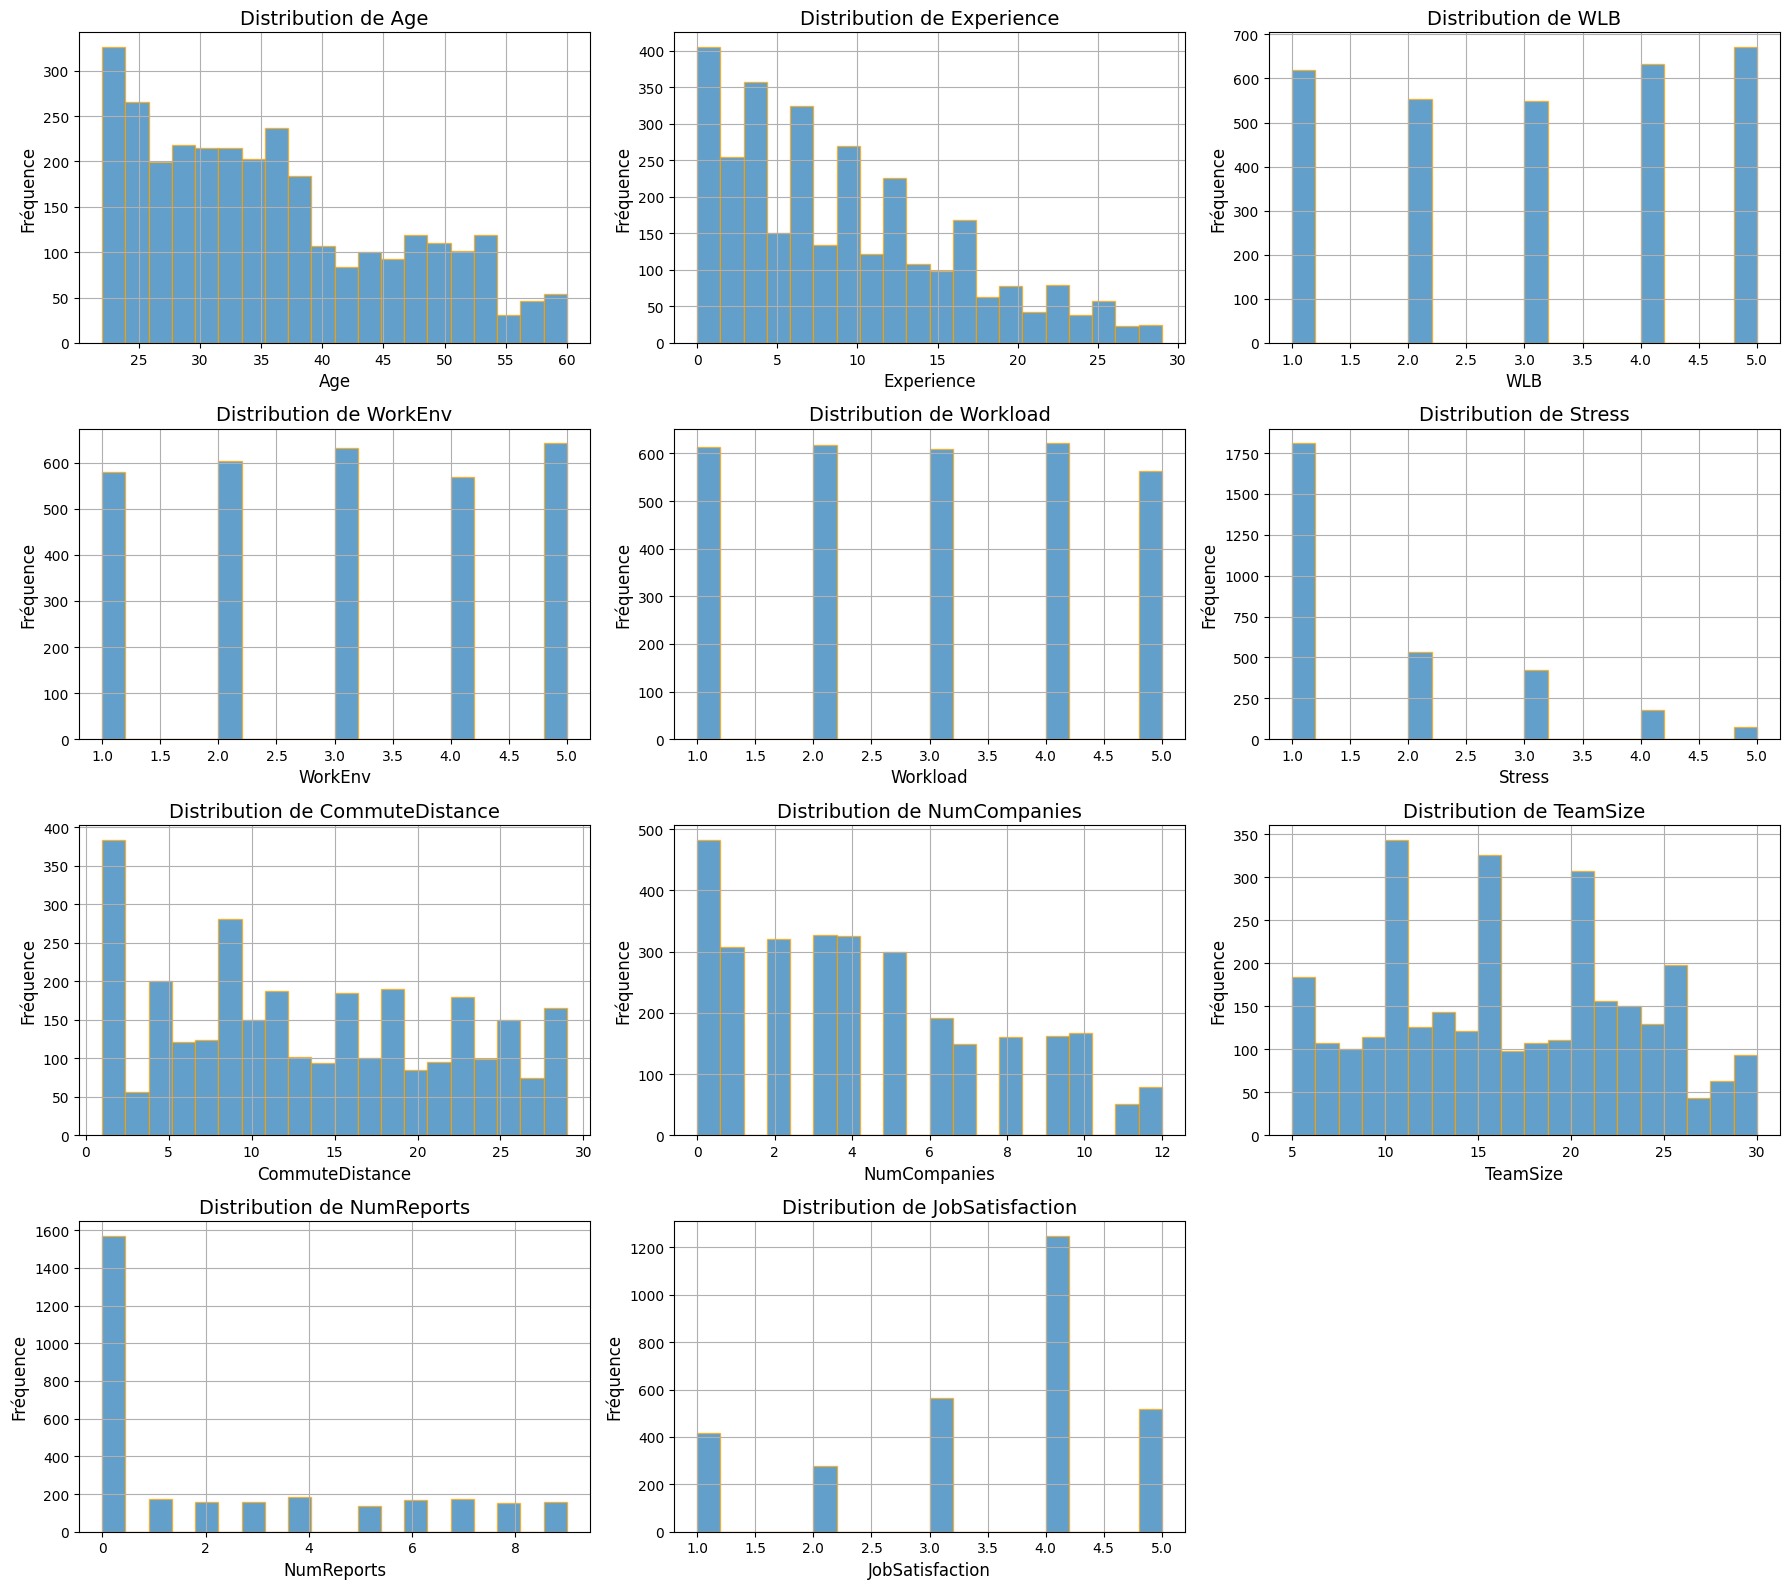

In [15]:
data_distribution(quant_features_int, columns=3, rows=4)

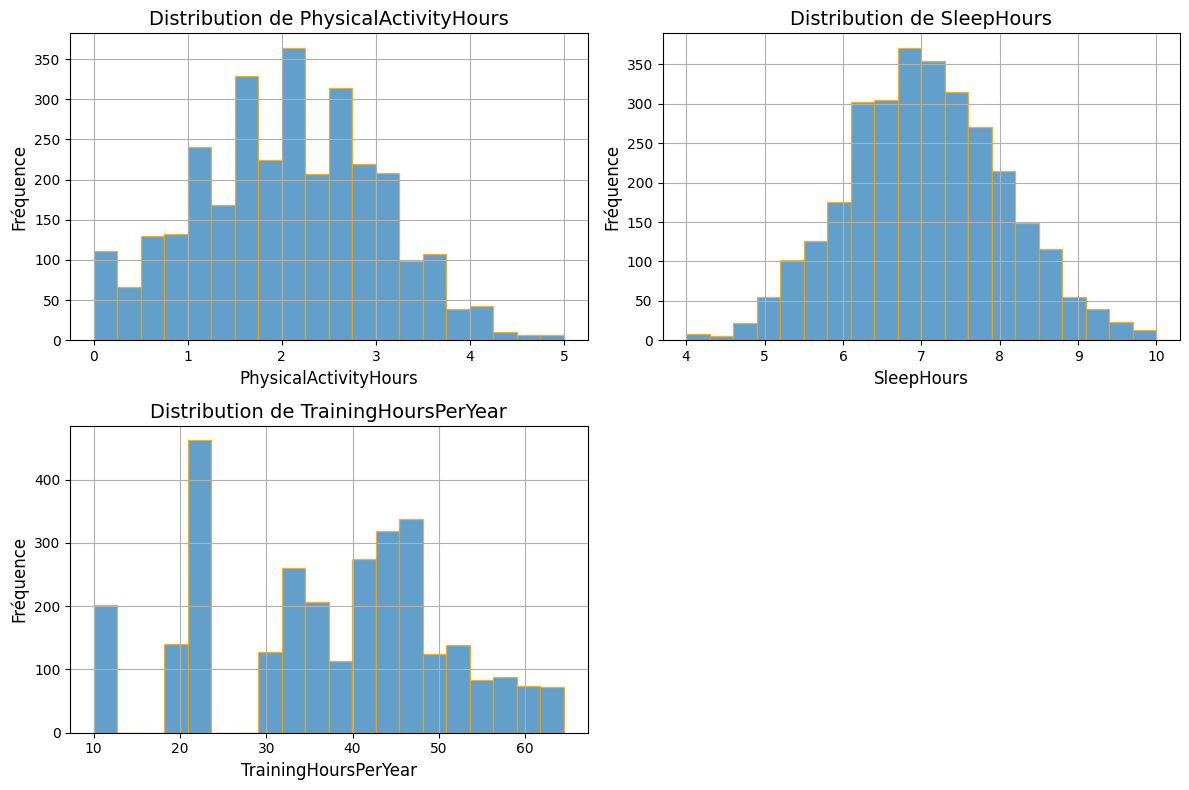

In [16]:
data_distribution(quant_features_float, columns=2, rows=2)

### Observing qualitative data

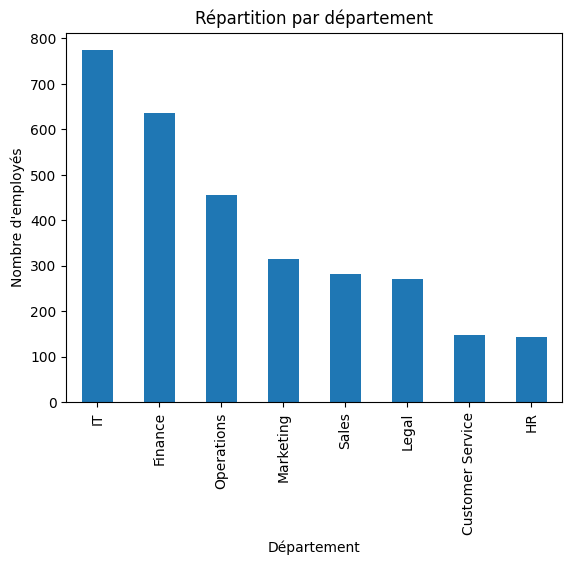

In [17]:
df['Dept'].value_counts().plot(kind='bar')
plt.title('Répartition par département')
plt.xlabel('Département')
plt.ylabel('Nombre d\'employés')
plt.show()

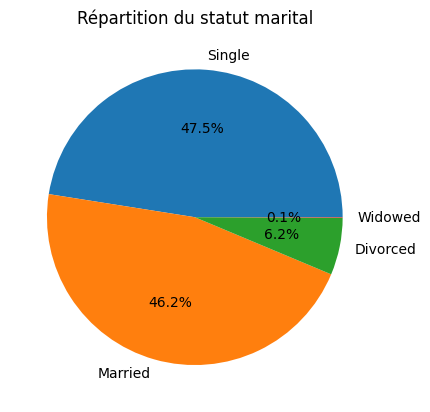

In [18]:
df['MaritalStatus'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Répartition du statut marital')
plt.ylabel('')
plt.show()

### Visualizing the target variable : Job Satisfaction

In [159]:
df['JobSatisfaction'].value_counts()

,count
JobSatisfaction,
4,1249
3,566
5,516
1,417
2,277


# Prétraitement des données

In [233]:
df_processed = df.drop('EmpID', axis=1)

#convert quanti variables using label encoding
categorical_cols = ['Gender', 'MaritalStatus', 'JobLevel', 'Dept', 'EmpType','EduLevel', 'CommuteMode']
le = LabelEncoder()
for col in categorical_cols:
    df_processed[col] = le.fit_transform(df_processed[col])
# boolean to numeric
df_processed['haveOT'] = df_processed['haveOT'].astype(int)

In [141]:
df_processed.info() # just un récapitulatif sur les transofrmations done

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3025 entries, 0 to 3024
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Gender                 3025 non-null   int64  
 1   Age                    3025 non-null   int64  
 2   MaritalStatus          3025 non-null   int64  
 3   JobLevel               3025 non-null   int64  
 4   Experience             3025 non-null   int64  
 5   Dept                   3025 non-null   int64  
 6   EmpType                3025 non-null   int64  
 7   WLB                    3025 non-null   int64  
 8   WorkEnv                3025 non-null   int64  
 9   PhysicalActivityHours  3025 non-null   float64
 10  Workload               3025 non-null   int64  
 11  Stress                 3025 non-null   int64  
 12  SleepHours             3025 non-null   float64
 13  CommuteMode            3025 non-null   int64  
 14  CommuteDistance        3025 non-null   int64  
 15  NumC

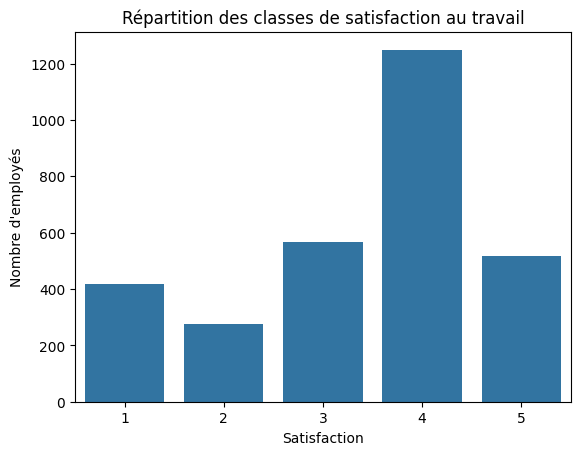

In [142]:
sns.countplot(x='JobSatisfaction', data=df_processed)
plt.title("Répartition des classes de satisfaction au travail")
plt.xlabel("Satisfaction")
plt.ylabel("Nombre d'employés")
plt.show()

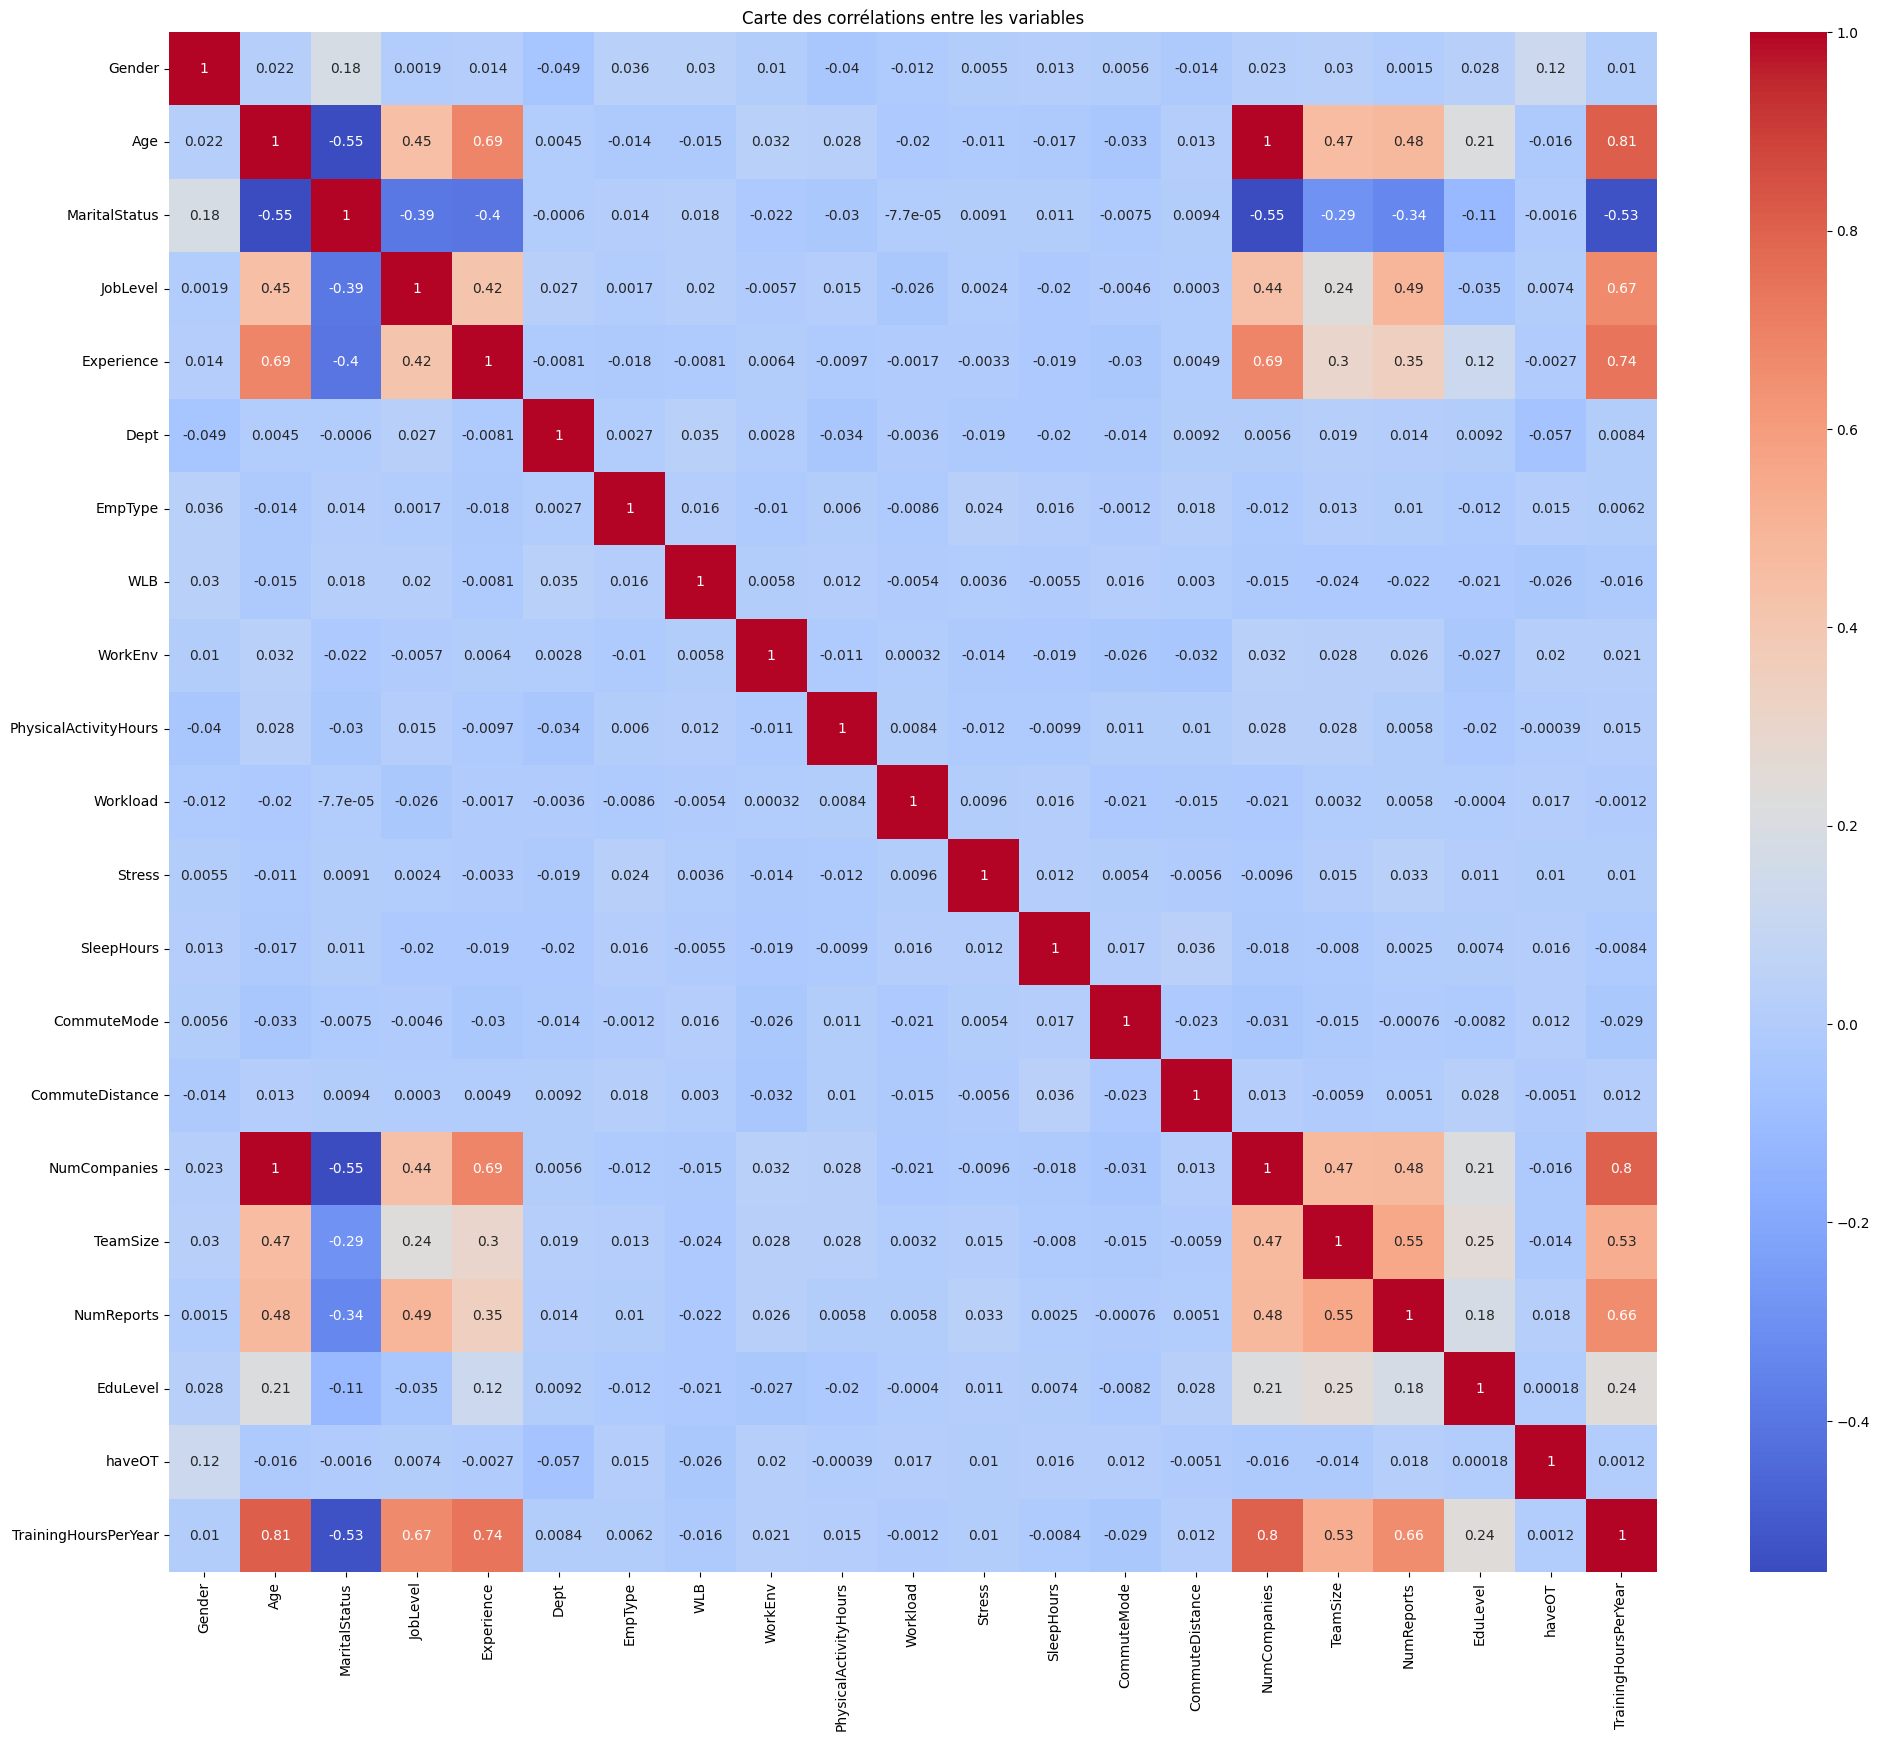

In [128]:
corr_matrix = df_processed.drop('JobSatisfaction',axis=1).corr()
plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Carte des corrélations entre les variables")
plt.show()

# But Descriptive de l'analyse discriminante : On cherche le groupe de sous-variables qui sépare aux mieux les classes

In [234]:
#Prepare features and target
X = df_processed.drop('JobSatisfaction',axis=1)
y = df_processed['JobSatisfaction']

In [235]:
# centrer et réduire bc ya une différence de grandeur d'échelle et d'unités entre les variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [236]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_scaled, y)

LinearDiscriminantAnalysis()

In [237]:
feature_names = X.columns
n_components = min(len(lda.explained_variance_ratio_), 2)
for i in range(n_components):
        print(f"\nLD{i+1} - Les variables les plus influentes:")

        coefficients = pd.DataFrame(
            lda.scalings_[:, i],
            index=feature_names,
            columns=[f'Coefficient']
        ).sort_values(by='Coefficient', key=abs, ascending=False)

        print("\nVariables positives (augmentent la satisfaction):")
        print(coefficients[coefficients['Coefficient'] > 0].head())

        print("\nVariables négatives (diminuent la satisfaction):")
        print(coefficients[coefficients['Coefficient'] < 0].head())


LD1 - Les variables les plus influentes:

Variables positives (augmentent la satisfaction):
              Coefficient
NumCompanies     0.709156
WorkEnv          0.626697
WLB              0.566413
SleepHours       0.431580
JobLevel         0.091715

Variables négatives (diminuent la satisfaction):
          Coefficient
Age         -0.686799
Workload    -0.580177
Stress      -0.480616
haveOT      -0.355368
EmpType     -0.058956

LD2 - Les variables les plus influentes:

Variables positives (augmentent la satisfaction):
              Coefficient
EduLevel         1.020607
NumCompanies     0.522322
JobLevel         0.438787
Experience       0.243928
EmpType          0.182871

Variables négatives (diminuent la satisfaction):
                       Coefficient
Age                      -0.694375
TrainingHoursPerYear     -0.563609
TeamSize                 -0.158484
WorkEnv                  -0.144920
PhysicalActivityHours    -0.097066


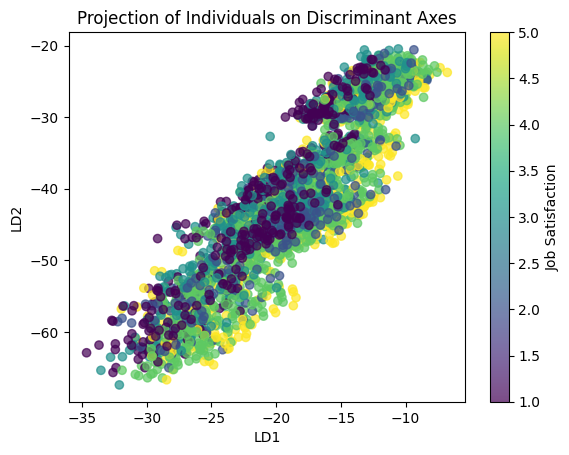

In [249]:
X_lda = lda.transform(X)
plt.scatter(
    X_lda[:, 0], X_lda[:, 1], c=y, cmap='viridis', alpha=0.7
)
plt.colorbar(label="Job Satisfaction")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("Projection of Individuals on Discriminant Axes")
plt.show()

# But Décisionnel de l'AD : Prédiction

In [241]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [242]:
lda_classifier = LinearDiscriminantAnalysis()
lda_classifier.fit(X_train, y_train)

LinearDiscriminantAnalysis()

In [243]:
y_pred = lda_classifier.predict(X_test)

### performance metrics

In [244]:
confusion_matrix(y_test,y_pred)

array([[ 53,   0,  31,  10,   0],
       [  6,   0,   1,  44,   0],
       [ 26,   0,  35,  41,   0],
       [  3,   0,  16, 232,   3],
       [ 10,   0,  17,  72,   5]])

In [246]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           1       0.54      0.56      0.55        94
           2       0.00      0.00      0.00        51
           3       0.35      0.34      0.35       102
           4       0.58      0.91      0.71       254
           5       0.62      0.05      0.09       104

    accuracy                           0.54       605
   macro avg       0.42      0.37      0.34       605
weighted avg       0.49      0.54      0.46       605



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [247]:
accuracy_score(y_test,y_pred)

0.5371900826446281

In [252]:
# roc curve

------------------------

# Fonction Discriminante quadratique

In [57]:
decision_values = lda.decision_function(X_train)

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearDiscriminantAnalysis was fitted without feature names
  warnings.warn(


In [218]:
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

QuadraticDiscriminantAnalysis()

In [219]:
y_pred_qda = qda.predict(X_test)

In [220]:
print(classification_report(y_test, y_pred_qda))

              precision    recall  f1-score   support

        High       0.53      0.27      0.36       104
         Low       0.50      0.38      0.43       145
      Medium       0.66      0.82      0.73       356

    accuracy                           0.62       605
   macro avg       0.56      0.49      0.51       605
weighted avg       0.60      0.62      0.59       605



In [221]:
confusion_matrix(y_test, y_pred_qda)

array([[ 28,  11,  65],
       [  3,  55,  87],
       [ 22,  43, 291]])

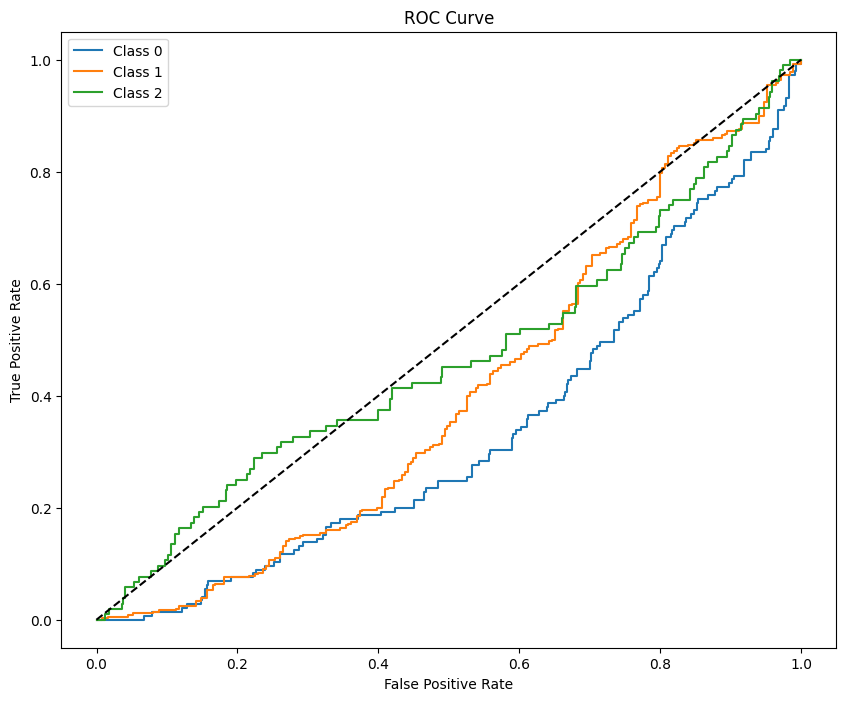

In [223]:
y_test_binarized = label_binarize(y_test, classes=['Low', 'Medium', 'High'])
y_score = qda.predict_proba(X_test)
n_classes = y_test_binarized.shape[1]

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    plt.plot(fpr, tpr, label=f'Class {i}')
plt.plot([0, 1], [0, 1], 'k--')
plt.legend()
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()